# GC2D HDF5 field-mode study

This notebook audits `data/potential/V1/PHI_2.h5` and visualizes 20 stored
Fourier-coefficient channels in addition to source fields 0 and 15. It keeps
three concepts separate:

- the raw `fields` channel index in the HDF5 file;
- the angular frequency declared by the aligned `freqs` entry;
- the mode-selection index accepted by `load_gc2d_h5_potential`, which is
  assigned only after zero/negative-frequency filtering and amplitude sorting.

The distinction matters for this file: nonzero spatial coefficients do not
necessarily have a nonzero declared temporal frequency.

## Configuration

`ADDITIONAL_FIELD_INDICES = None` selects the 20 strongest independent stored
channels by spatial RMS, excluding fields 0 and 15. Set it to an explicit
20-element tuple to inspect a different selection. The independent half of a
real-valued Fourier representation is used so conjugate partners are not shown
twice.

`MODE_COMPONENT` may be `"magnitude"`, `"real"`, `"imaginary"`, or `"phase"`.
All scientific choices and tolerances used by the audit are explicit below.

In [1]:
%matplotlib inline

from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, Markdown, display

from diagnostics.paths import find_project_root
from potential import load_gc2d_h5_potential

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / "data/potential/V1/PHI_2.h5"

REFERENCE_FIELD_INDICES = (0, 15)
ADDITIONAL_MODE_COUNT = 20
ADDITIONAL_FIELD_INDICES = None
MODE_COMPONENT = "magnitude"
FREQUENCY_ZERO_ATOL = 1e-5
CONJUGACY_RELATIVE_TOL = 1e-12

MAGNETIC_FIELD = 1.5
CHARACTERISTIC_LENGTH = 0.06
INTERPOLATION_ORDER = 3

if not DATA_PATH.is_file():
    raise FileNotFoundError(f"HDF5 potential not found: {DATA_PATH}")
if MODE_COMPONENT not in {"magnitude", "real", "imaginary", "phase"}:
    raise ValueError(f"Unsupported MODE_COMPONENT: {MODE_COMPONENT}")

## File structure and declared frequencies

Only metadata and coordinate arrays are read in this section. The large
`fields` dataset remains lazy until the blockwise scan below.

Source: /home/juan/Proyectos/GC2D_intranet/data/potential/V1/PHI_2.h5
File size: 572.54 MiB
Datasets:
  Rcells: {'shape': (256,), 'dtype': 'float64', 'chunks': (256,), 'compression': 'gzip'}
  Zcells: {'shape': (256,), 'dtype': 'float64', 'chunks': (256,), 'compression': 'gzip'}
  fields: {'shape': (602, 256, 256), 'dtype': 'complex128', 'chunks': (38, 16, 16), 'compression': 'gzip'}
  freqs: {'shape': (602,), 'dtype': 'float64', 'chunks': (602,), 'compression': 'gzip'}
Root attributes: {'rho0': array([0.00022764]), 'tau0': array([1.03642688e-08])}
R range: [0.000703125, 0.18] (256 cells)
Z range: [0.0003515625, 0.179648437] (256 cells)
Stored field channels: 602
Declared near-zero frequencies: 601
Declared positive frequencies: 1
Declared negative frequencies: 0
Positive-frequency source indices: [15]


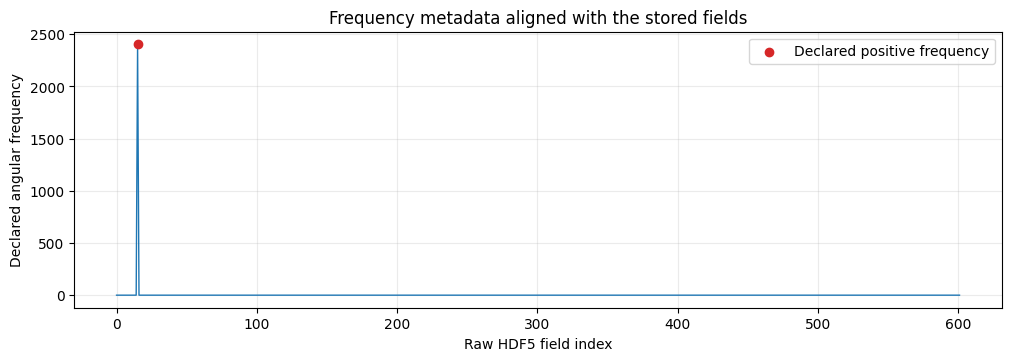

In [2]:
with h5py.File(DATA_PATH, "r") as h5:
    dataset_inventory = {
        name: {
            "shape": dataset.shape,
            "dtype": str(dataset.dtype),
            "chunks": dataset.chunks,
            "compression": dataset.compression,
        }
        for name, dataset in h5.items()
    }
    source_attributes = {name: np.asarray(value) for name, value in h5.attrs.items()}
    source_r = np.asarray(h5["Rcells"], dtype=float)
    source_z = np.asarray(h5["Zcells"], dtype=float)
    declared_frequencies = np.asarray(h5["freqs"], dtype=float)
    field_shape = h5["fields"].shape

field_count = field_shape[0]
zero_frequency_mask = np.isclose(
    declared_frequencies,
    0.0,
    atol=FREQUENCY_ZERO_ATOL,
    rtol=0.0,
)
positive_frequency_indices = np.flatnonzero(
    (~zero_frequency_mask) & (declared_frequencies > 0.0)
)
negative_frequency_indices = np.flatnonzero(
    (~zero_frequency_mask) & (declared_frequencies < 0.0)
)

print(f"Source: {DATA_PATH}")
print(f"File size: {DATA_PATH.stat().st_size / 2**20:.2f} MiB")
print("Datasets:")
for name, description in dataset_inventory.items():
    print(f"  {name}: {description}")
print(f"Root attributes: {source_attributes}")
print(f"R range: [{source_r[0]:.9g}, {source_r[-1]:.9g}] ({source_r.size} cells)")
print(f"Z range: [{source_z[0]:.9g}, {source_z[-1]:.9g}] ({source_z.size} cells)")
print(f"Stored field channels: {field_count}")
print(f"Declared near-zero frequencies: {np.count_nonzero(zero_frequency_mask)}")
print(f"Declared positive frequencies: {positive_frequency_indices.size}")
print(f"Declared negative frequencies: {negative_frequency_indices.size}")
print(f"Positive-frequency source indices: {positive_frequency_indices.tolist()}")

figure, axis = plt.subplots(figsize=(10, 3.5), constrained_layout=True)
axis.plot(np.arange(field_count), declared_frequencies, linewidth=1.0)
axis.scatter(
    positive_frequency_indices,
    declared_frequencies[positive_frequency_indices],
    color="tab:red",
    zorder=3,
    label="Declared positive frequency",
)
axis.set(
    xlabel="Raw HDF5 field index",
    ylabel="Declared angular frequency",
    title="Frequency metadata aligned with the stored fields",
)
axis.grid(alpha=0.25)
axis.legend()
plt.show()

## Current public-loader interpretation

The public loader treats the first near-zero-frequency channel as the real mean
field, discards all other near-zero and negative-frequency channels, and retains
positive-frequency channels as dynamic modes. Its default selector `(0, 1)`
therefore means “mean plus first retained positive mode”; it does **not** mean
raw source channels 0 and 1.

In [3]:
runtime_potential = load_gc2d_h5_potential(
    DATA_PATH,
    B=MAGNETIC_FIELD,
    characteristic_length=CHARACTERISTIC_LENGTH,
    indx=(0, 1),
    interpolation_order=INTERPOLATION_ORDER,
)

runtime_metadata = runtime_potential.metadata
if runtime_metadata is None:
    raise RuntimeError("The HDF5 loader did not retain source metadata.")
runtime_source_indices = runtime_metadata.source_field_indices.tolist()
print("Loader selection index: (0, 1)")
print("Mean source field index: 0")
print(f"Dynamic source field indices: {runtime_source_indices}")
print(
    "Dynamic source angular frequencies: "
    f"{runtime_metadata.source_frequencies.tolist()}"
)
print(f"Normalized cycle frequencies: {runtime_potential.frequencies.tolist()}")

assert runtime_source_indices == [REFERENCE_FIELD_INDICES[1]]

Loader selection index: (0, 1)
Mean source field index: 0
Dynamic source field indices: [15]
Dynamic source angular frequencies: [2404.106675108847]
Normalized cycle frequencies: [1.0]


## Blockwise coefficient scan

The scan reads complete HDF5 first-axis chunks. This avoids loading the full
roughly 600 MiB complex array into memory while still computing an amplitude
summary for every stored channel. Spatial RMS is used for ranking because it
measures the complete coefficient field rather than a single extreme sample.

In [4]:
FIELD_STAT_DTYPE = np.dtype(
    [
        ("source_index", np.int64),
        ("frequency", np.float64),
        ("rms_magnitude", np.float64),
        ("max_magnitude", np.float64),
        ("real_range", np.float64),
        ("imaginary_range", np.float64),
    ]
)


def scan_field_statistics(path):
    '''Compute one compact amplitude record per stored field channel.'''
    with h5py.File(path, "r") as h5:
        dataset = h5["fields"]
        frequencies = np.asarray(h5["freqs"], dtype=float)
        block_size = dataset.chunks[0] if dataset.chunks else 32
        records = np.empty(dataset.shape[0], dtype=FIELD_STAT_DTYPE)

        for start in range(0, dataset.shape[0], block_size):
            stop = min(start + block_size, dataset.shape[0])
            block = np.asarray(dataset[start:stop], dtype=np.complex128)
            squared_magnitude = block.real**2 + block.imag**2
            target = records[start:stop]
            target["source_index"] = np.arange(start, stop)
            target["frequency"] = frequencies[start:stop]
            target["rms_magnitude"] = np.sqrt(
                np.mean(squared_magnitude, axis=(1, 2))
            )
            target["max_magnitude"] = np.sqrt(
                np.max(squared_magnitude, axis=(1, 2))
            )
            target["real_range"] = np.ptp(block.real, axis=(1, 2))
            target["imaginary_range"] = np.ptp(block.imag, axis=(1, 2))

    return records


def display_field_table(records):
    '''Display selected structured-array rows as a compact HTML table.'''
    headers = (
        "Source index",
        "Declared frequency",
        "RMS |coefficient|",
        "Max |coefficient|",
        "Real range",
        "Imaginary range",
    )
    rows = []
    for record in records:
        rows.append(
            "<tr>"
            f"<td>{int(record['source_index'])}</td>"
            f"<td>{record['frequency']:.9g}</td>"
            f"<td>{record['rms_magnitude']:.6g}</td>"
            f"<td>{record['max_magnitude']:.6g}</td>"
            f"<td>{record['real_range']:.6g}</td>"
            f"<td>{record['imaginary_range']:.6g}</td>"
            "</tr>"
        )
    header = "".join(f"<th>{label}</th>" for label in headers)
    display(HTML(f"<table><thead><tr>{header}</tr></thead><tbody>{''.join(rows)}</tbody></table>"))


field_statistics = scan_field_statistics(DATA_PATH)
assert field_statistics.size == field_count
assert np.all(np.isfinite(field_statistics["rms_magnitude"]))

# For N even, indices 1 through N/2 contain one representative of each
# conjugate pair plus the self-conjugate Nyquist channel.
independent_indices = np.arange(1, field_count // 2 + 1, dtype=int)
eligible_indices = independent_indices[
    ~np.isin(independent_indices, REFERENCE_FIELD_INDICES)
]

if ADDITIONAL_FIELD_INDICES is None:
    ranking = np.argsort(
        field_statistics["rms_magnitude"][eligible_indices]
    )[::-1]
    selected_additional_indices = eligible_indices[ranking[:ADDITIONAL_MODE_COUNT]]
else:
    selected_additional_indices = np.asarray(ADDITIONAL_FIELD_INDICES, dtype=int)

if selected_additional_indices.size != ADDITIONAL_MODE_COUNT:
    raise ValueError(
        f"Expected {ADDITIONAL_MODE_COUNT} additional indices, received "
        f"{selected_additional_indices.size}."
    )
if np.unique(selected_additional_indices).size != ADDITIONAL_MODE_COUNT:
    raise ValueError("Additional field indices must be unique.")
if np.any((selected_additional_indices < 0) | (selected_additional_indices >= field_count)):
    raise IndexError("An additional field index is outside the HDF5 dataset.")
if np.intersect1d(selected_additional_indices, REFERENCE_FIELD_INDICES).size:
    raise ValueError("Additional fields must exclude reference fields 0 and 15.")

print(
    "Selected additional source indices (descending spatial RMS): "
    f"{selected_additional_indices.tolist()}"
)
display_field_table(field_statistics[selected_additional_indices])

Selected additional source indices (descending spatial RMS): [16, 10, 12, 4, 11, 5, 3, 1, 24, 9, 13, 20, 2, 18, 7, 6, 17, 8, 14, 21]


Source index,Declared frequency,RMS |coefficient|,Max |coefficient|,Real range,Imaginary range
16,0,0.133949,0.349926,0.612867,0.652808
10,0,0.121486,0.336043,0.599217,0.600733
12,0,0.119103,0.343731,0.605496,0.64122
4,0,0.112128,0.306735,0.481352,0.44745
11,0,0.10626,0.345136,0.649301,0.613264
5,0,0.102949,0.267787,0.474172,0.402353
3,0,0.10291,0.266885,0.433319,0.498741
1,0,0.0989863,0.286815,0.498925,0.443168
24,0,0.0984796,0.294904,0.557036,0.542885
9,0,0.0910113,0.252108,0.433525,0.429294


## Independent coefficient spectrum

The spectrum below uses one member of each conjugate pair. Selected channels
are highlighted. The vertical axis is logarithmic so weak stored coefficients
remain visible.

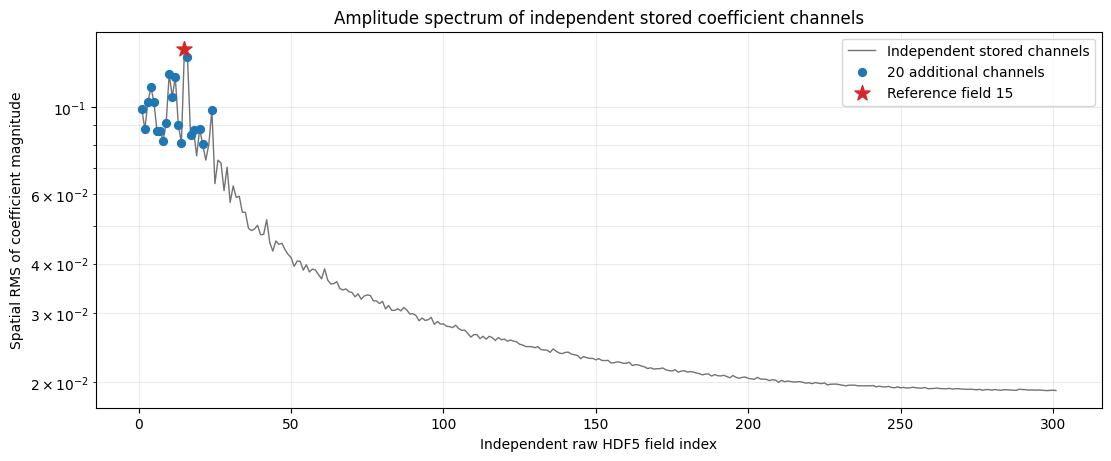

Reference field 15 share of non-DC coefficient L2 power: 4.342%
Selected 20 share of non-DC coefficient L2 power: 42.410%
Reference plus selected 20 share: 46.752%


In [5]:
figure, axis = plt.subplots(figsize=(11, 4.5), constrained_layout=True)
axis.semilogy(
    independent_indices,
    field_statistics["rms_magnitude"][independent_indices],
    color="0.45",
    linewidth=1.0,
    label="Independent stored channels",
)
axis.scatter(
    selected_additional_indices,
    field_statistics["rms_magnitude"][selected_additional_indices],
    color="tab:blue",
    s=32,
    zorder=3,
    label="20 additional channels",
)
axis.scatter(
    [REFERENCE_FIELD_INDICES[1]],
    [field_statistics["rms_magnitude"][REFERENCE_FIELD_INDICES[1]]],
    color="tab:red",
    marker="*",
    s=130,
    zorder=4,
    label="Reference field 15",
)
axis.set(
    xlabel="Independent raw HDF5 field index",
    ylabel="Spatial RMS of coefficient magnitude",
    title="Amplitude spectrum of independent stored coefficient channels",
)
axis.grid(alpha=0.25, which="both")
axis.legend()
plt.show()

pairable_indices = np.arange(1, (field_count + 1) // 2, dtype=int)
pair_weights = 2.0 * field_statistics["rms_magnitude"][pairable_indices] ** 2
non_dc_power = float(np.sum(pair_weights))
if field_count % 2 == 0:
    nyquist_index = field_count // 2
    non_dc_power += float(field_statistics["rms_magnitude"][nyquist_index] ** 2)

reference_power = float(
    2.0 * field_statistics["rms_magnitude"][REFERENCE_FIELD_INDICES[1]] ** 2
)
additional_power = float(
    np.sum(2.0 * field_statistics["rms_magnitude"][selected_additional_indices] ** 2)
)
print(f"Reference field 15 share of non-DC coefficient L2 power: {reference_power / non_dc_power:.3%}")
print(f"Selected 20 share of non-DC coefficient L2 power: {additional_power / non_dc_power:.3%}")
print(f"Reference plus selected 20 share: {(reference_power + additional_power) / non_dc_power:.3%}")

## Conjugate-symmetry audit

For an array with `N` temporal Fourier channels, a real reconstructed signal
should satisfy $C_{N-k}=\overline{C_k}$. The audit reads paired blocks and reports
the relative Frobenius-norm defect. Channel 0 and, for even `N`, channel `N/2`
are self-conjugate and should be real.

Maximum relative conjugacy defect: 5.942e-16
Median relative conjugacy defect: 4.146e-16
Fields 15 and 587 relative defect: 1.782e-16
Field 0 maximum imaginary magnitude: 0.000e+00
Field 301 maximum imaginary magnitude: 1.918e-17


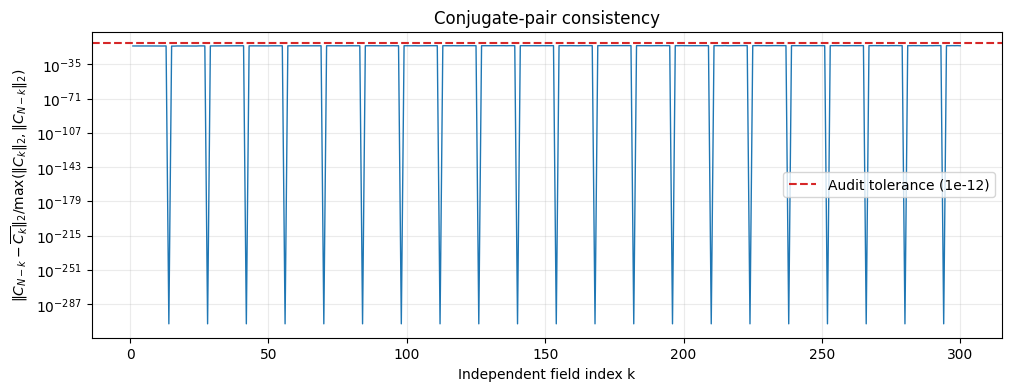

In [6]:
def conjugacy_errors(path):
    '''Return paired-channel relative defects without retaining all fields.'''
    with h5py.File(path, "r") as h5:
        dataset = h5["fields"]
        count = dataset.shape[0]
        block_size = dataset.chunks[0] if dataset.chunks else 32
        indices = np.arange(1, (count + 1) // 2, dtype=int)
        errors = np.empty(indices.size, dtype=float)

        for position in range(0, indices.size, block_size):
            current = indices[position : position + block_size]
            left = np.asarray(
                dataset[int(current[0]) : int(current[-1]) + 1],
                dtype=np.complex128,
            )
            partner_start = count - int(current[-1])
            partner_stop = count - int(current[0]) + 1
            right = np.asarray(
                dataset[partner_start:partner_stop],
                dtype=np.complex128,
            )[::-1]

            differences = np.linalg.norm(
                (right - np.conjugate(left)).reshape(current.size, -1),
                axis=1,
            )
            scales = np.maximum(
                np.linalg.norm(left.reshape(current.size, -1), axis=1),
                np.linalg.norm(right.reshape(current.size, -1), axis=1),
            )
            errors[position : position + current.size] = differences / np.maximum(
                scales,
                np.finfo(float).tiny,
            )

        dc_imaginary_max = float(np.max(np.abs(np.asarray(dataset[0]).imag)))
        nyquist_imaginary_max = (
            float(np.max(np.abs(np.asarray(dataset[count // 2]).imag)))
            if count % 2 == 0
            else None
        )

    return indices, errors, dc_imaginary_max, nyquist_imaginary_max


(
    conjugacy_indices,
    relative_conjugacy_errors,
    dc_imaginary_max,
    nyquist_imaginary_max,
) = conjugacy_errors(DATA_PATH)

maximum_conjugacy_error = float(np.max(relative_conjugacy_errors))
median_conjugacy_error = float(np.median(relative_conjugacy_errors))
field_15_position = int(np.flatnonzero(conjugacy_indices == 15)[0])
field_15_pair_index = field_count - 15

print(f"Maximum relative conjugacy defect: {maximum_conjugacy_error:.3e}")
print(f"Median relative conjugacy defect: {median_conjugacy_error:.3e}")
print(
    f"Fields 15 and {field_15_pair_index} relative defect: "
    f"{relative_conjugacy_errors[field_15_position]:.3e}"
)
print(f"Field 0 maximum imaginary magnitude: {dc_imaginary_max:.3e}")
if nyquist_imaginary_max is not None:
    print(
        f"Field {field_count // 2} maximum imaginary magnitude: "
        f"{nyquist_imaginary_max:.3e}"
    )

assert maximum_conjugacy_error < CONJUGACY_RELATIVE_TOL

figure, axis = plt.subplots(figsize=(10, 3.8), constrained_layout=True)
axis.semilogy(
    conjugacy_indices,
    np.maximum(relative_conjugacy_errors, np.finfo(float).tiny),
    linewidth=1.0,
)
axis.axhline(
    CONJUGACY_RELATIVE_TOL,
    color="tab:red",
    linestyle="--",
    label=f"Audit tolerance ({CONJUGACY_RELATIVE_TOL:.0e})",
)
axis.set(
    xlabel="Independent field index k",
    ylabel=r"$\|C_{N-k}-\overline{C_k}\|_2 / \max(\|C_k\|_2,\|C_{N-k}\|_2)$",
    title="Conjugate-pair consistency",
)
axis.grid(alpha=0.25, which="both")
axis.legend()
plt.show()

## Reference fields 0 and 15

Field 0 is shown through its real component. The complex coefficient in field
15 uses the component selected in the configuration. Axes are the dimensional
`Rcells` and `Zcells` coordinates stored in the file; no runtime
nondimensionalization or interpolation is applied.

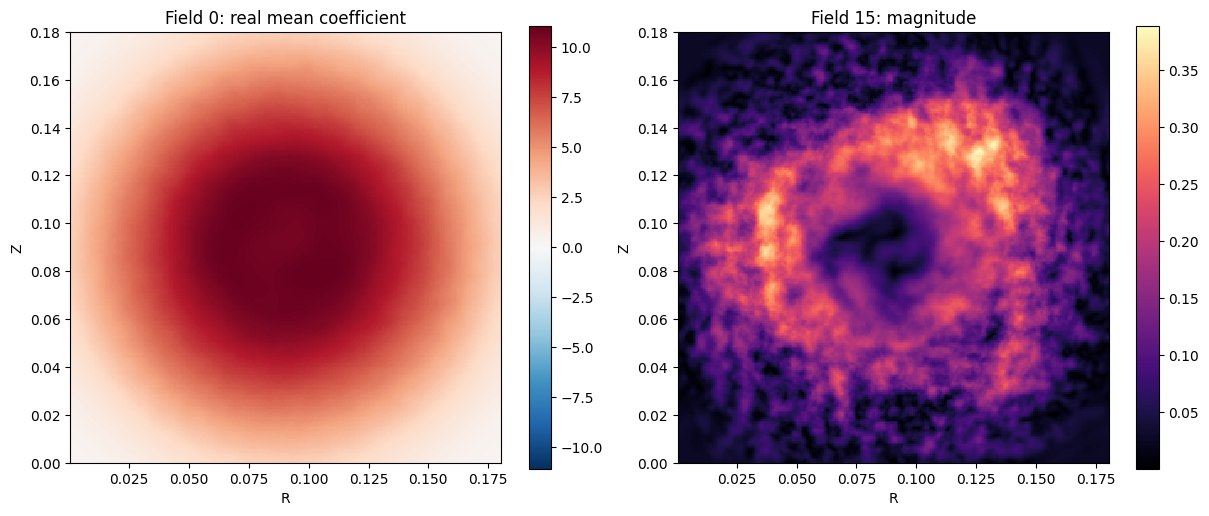

In [7]:
def load_selected_fields(path, indices):
    '''Load selected slices while decompressing each first-axis chunk once.'''
    requested = np.unique(np.asarray(indices, dtype=int))
    loaded = {}
    with h5py.File(path, "r") as h5:
        dataset = h5["fields"]
        chunk_size = dataset.chunks[0] if dataset.chunks else 1
        chunk_starts = np.unique((requested // chunk_size) * chunk_size)
        for start in chunk_starts:
            stop = min(int(start + chunk_size), dataset.shape[0])
            block = np.asarray(dataset[int(start):stop], dtype=np.complex128)
            for index in requested[(requested >= start) & (requested < stop)]:
                loaded[int(index)] = block[int(index - start)].copy()
    return loaded


def selected_component(field, component):
    '''Return the configured real-valued view of one complex coefficient.'''
    if component == "magnitude":
        return np.abs(field)
    if component == "real":
        return field.real
    if component == "imaginary":
        return field.imag
    return np.angle(field)


all_display_indices = (*REFERENCE_FIELD_INDICES, *selected_additional_indices)
display_fields = load_selected_fields(DATA_PATH, all_display_indices)

reference_views = (
    (display_fields[0].real, "Field 0: real mean coefficient", "RdBu_r"),
    (
        selected_component(display_fields[15], MODE_COMPONENT),
        f"Field 15: {MODE_COMPONENT}",
        "twilight" if MODE_COMPONENT == "phase" else (
            "magma" if MODE_COMPONENT == "magnitude" else "RdBu_r"
        ),
    ),
)

figure, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for axis, (values, title, color_map) in zip(axes, reference_views):
    if color_map == "RdBu_r":
        bound = max(float(np.max(np.abs(values))), np.finfo(float).tiny)
        color_limits = {"vmin": -bound, "vmax": bound}
    elif MODE_COMPONENT == "phase" and "Field 15" in title:
        color_limits = {"vmin": -np.pi, "vmax": np.pi}
    else:
        color_limits = {"vmin": float(np.min(values)), "vmax": float(np.max(values))}
    mesh = axis.pcolormesh(
        source_r,
        source_z,
        values,
        shading="auto",
        cmap=color_map,
        **color_limits,
    )
    figure.colorbar(mesh, ax=axis)
    axis.set(xlabel="R", ylabel="Z", title=title, aspect="equal")
plt.show()

## Twenty additional independent channels

All panels use one shared color scale, allowing direct amplitude comparison.
The title of each panel gives the raw source index and spatial RMS magnitude.
Change `MODE_COMPONENT` in the configuration to inspect phase or individual
Cartesian components.

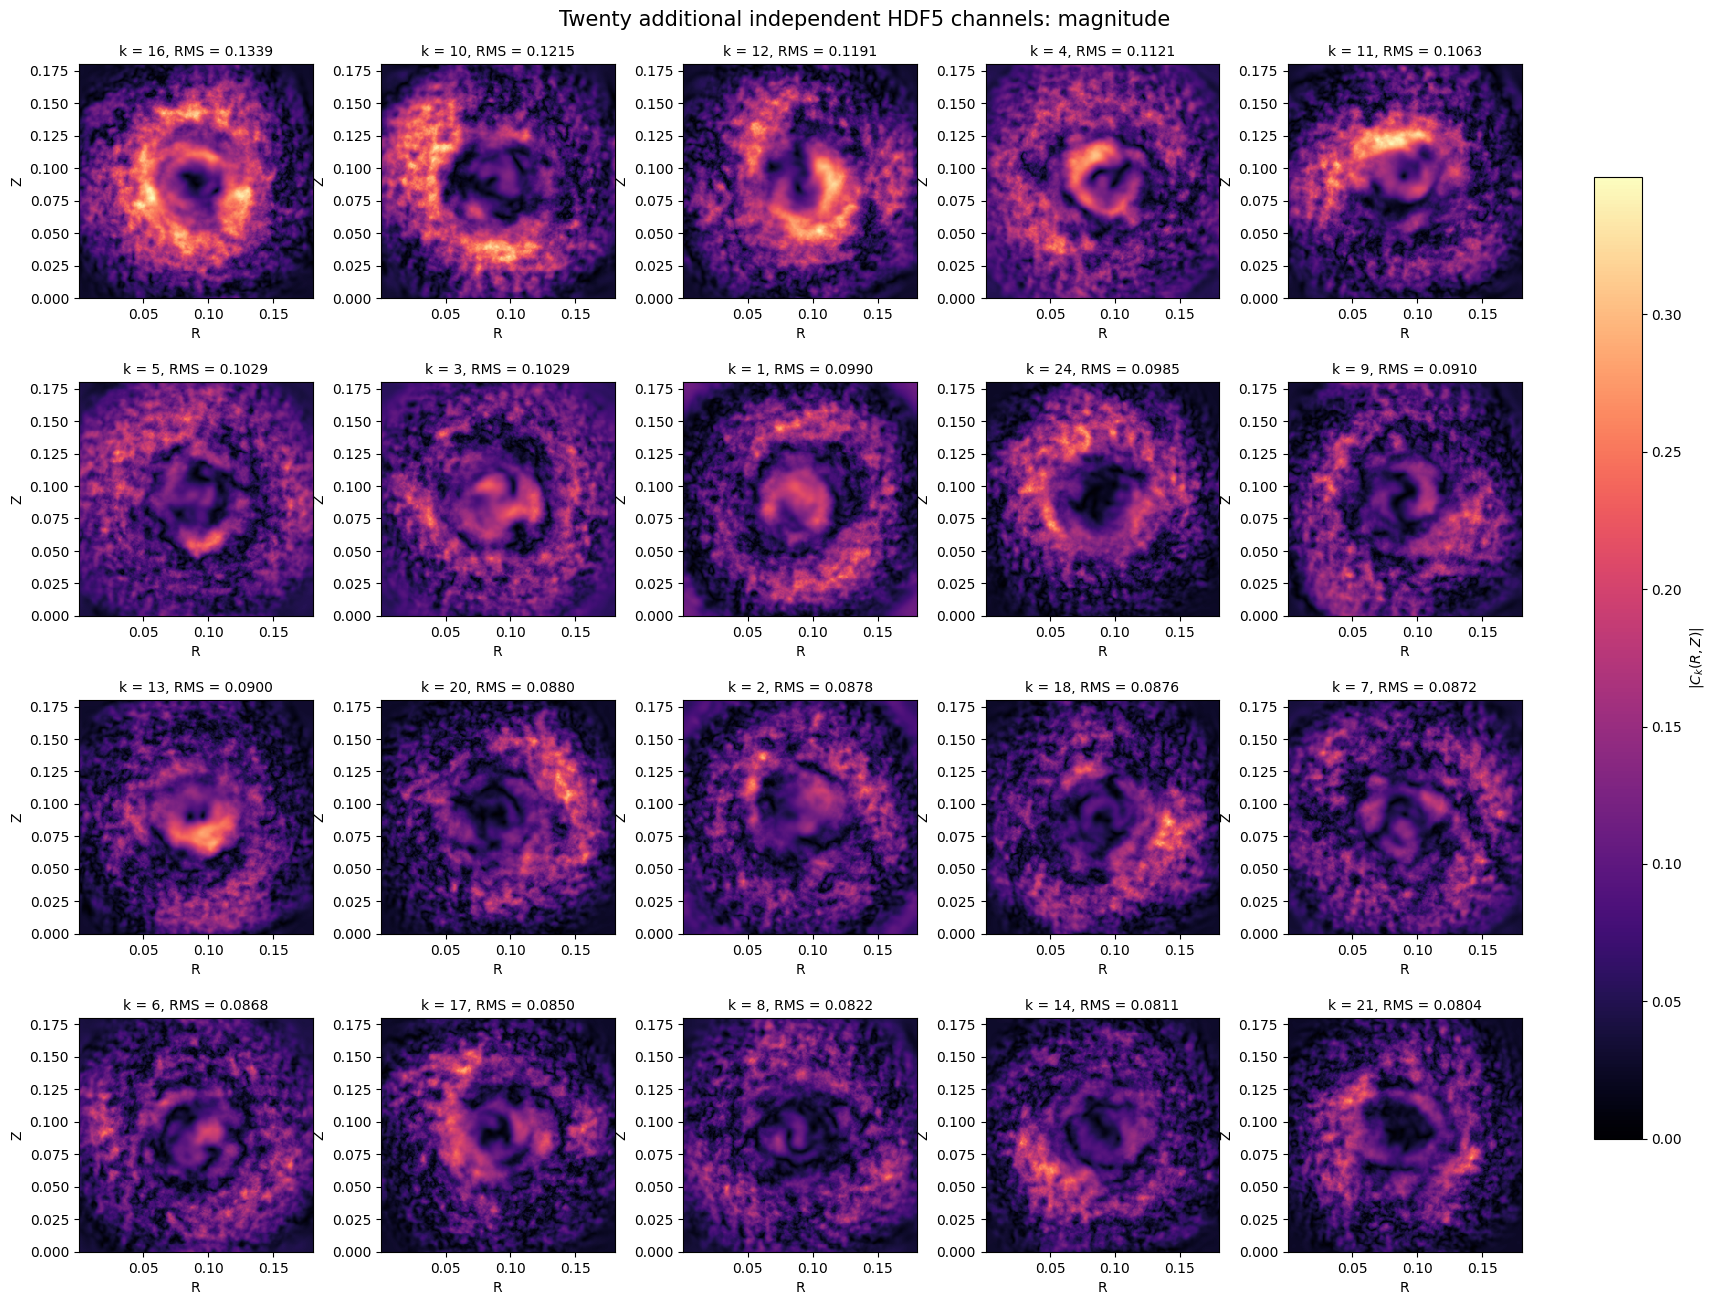

In [8]:
additional_views = np.asarray(
    [
        selected_component(display_fields[int(index)], MODE_COMPONENT)
        for index in selected_additional_indices
    ]
)

if MODE_COMPONENT == "magnitude":
    color_map = "magma"
    color_limits = {"vmin": 0.0, "vmax": float(np.max(additional_views))}
    color_label = r"$|C_k(R,Z)|$"
elif MODE_COMPONENT == "phase":
    color_map = "twilight"
    color_limits = {"vmin": -np.pi, "vmax": np.pi}
    color_label = r"$\arg C_k(R,Z)$"
else:
    color_map = "RdBu_r"
    bound = max(float(np.max(np.abs(additional_views))), np.finfo(float).tiny)
    color_limits = {"vmin": -bound, "vmax": bound}
    color_label = f"{MODE_COMPONENT.capitalize()} coefficient"

figure, axes = plt.subplots(4, 5, figsize=(17, 13), constrained_layout=True)
for axis, index, values in zip(
    axes.flat,
    selected_additional_indices,
    additional_views,
):
    mesh = axis.pcolormesh(
        source_r,
        source_z,
        values,
        shading="auto",
        cmap=color_map,
        **color_limits,
    )
    rms = field_statistics["rms_magnitude"][int(index)]
    axis.set_title(f"k = {int(index)}, RMS = {rms:.4f}", fontsize=10)
    axis.set_aspect("equal")
    axis.set_xlabel("R")
    axis.set_ylabel("Z")

figure.colorbar(mesh, ax=axes, shrink=0.78, label=color_label)
figure.suptitle(
    f"Twenty additional independent HDF5 channels: {MODE_COMPONENT}",
    fontsize=15,
)
plt.show()

## Data-driven interpretation

The final cell reports conclusions from the arrays calculated above. In
particular, it warns when spatially nonzero stored channels carry near-zero
frequency metadata and are consequently excluded from the current runtime
reconstruction.

In [9]:
nonreference_zero_frequency = np.flatnonzero(zero_frequency_mask)
nonreference_zero_frequency = nonreference_zero_frequency[
    nonreference_zero_frequency != REFERENCE_FIELD_INDICES[0]
]
spatially_nonzero = (
    field_statistics["max_magnitude"][nonreference_zero_frequency] > 0.0
)
excluded_nonzero_count = int(np.count_nonzero(spatially_nonzero))
selected_zero_frequency_count = int(
    np.count_nonzero(zero_frequency_mask[selected_additional_indices])
)

summary = f'''
### Computed findings

- The file contains **{field_count}** stored complex field channels on a
  **{field_shape[1]} × {field_shape[2]}** spatial grid.
- `freqs` declares **{np.count_nonzero(zero_frequency_mask)}** near-zero,
  **{positive_frequency_indices.size}** positive, and
  **{negative_frequency_indices.size}** negative frequencies at an absolute
  zero tolerance of `{FREQUENCY_ZERO_ATOL:g}`.
- The public loader's default `(0, 1)` selection uses source field 0 as the
  mean and source field **{runtime_source_indices[0]}** as its only dynamic mode.
- The maximum conjugate-pair defect is **{maximum_conjugacy_error:.3e}**;
  field 15 is paired with field **{field_15_pair_index}**. The stored coefficient
  array is therefore consistent with a real-signal Fourier representation to
  the configured tolerance.
- **{excluded_nonzero_count}** spatially nonzero channels other than field 0
  have near-zero declared frequencies. All **{selected_zero_frequency_count}**
  of the 20 additional default selections fall into this category.
- The 20 selected independent channels account for **{additional_power / non_dc_power:.2%}**
  of non-DC coefficient L2 power; field 15 accounts for
  **{reference_power / non_dc_power:.2%}**.

The additional panels are therefore valid visualizations of stored Fourier
coefficient channels, but they are **not additional temporal modes under the
current loader contract**. Assigning them physical frequencies or adding them
to a time-dependent simulation requires clarification or correction of the
`freqs` metadata first.
'''
display(Markdown(summary))


### Computed findings

- The file contains **602** stored complex field channels on a
  **256 × 256** spatial grid.
- `freqs` declares **601** near-zero,
  **1** positive, and
  **0** negative frequencies at an absolute
  zero tolerance of `1e-05`.
- The public loader's default `(0, 1)` selection uses source field 0 as the
  mean and source field **15** as its only dynamic mode.
- The maximum conjugate-pair defect is **5.942e-16**;
  field 15 is paired with field **587**. The stored coefficient
  array is therefore consistent with a real-signal Fourier representation to
  the configured tolerance.
- **600** spatially nonzero channels other than field 0
  have near-zero declared frequencies. All **20**
  of the 20 additional default selections fall into this category.
- The 20 selected independent channels account for **42.41%**
  of non-DC coefficient L2 power; field 15 accounts for
  **4.34%**.

The additional panels are therefore valid visualizations of stored Fourier
coefficient channels, but they are **not additional temporal modes under the
current loader contract**. Assigning them physical frequencies or adding them
to a time-dependent simulation requires clarification or correction of the
`freqs` metadata first.
